# vigloo_shortform 테이블과 longform_dramas 테이블 (MySQL) 비교 분석

## 1. 환경 설정

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pymysql
import plotly.graph_objects as go

load_dotenv()

db_host = os.getenv('MYSQL_HOST', 'localhost')
db_user = os.getenv('MYSQL_USER', 'root')
db_pw   = os.getenv('MYSQL_PASSWORD', '')
db_name = os.getenv('MYSQL_DB', 'youtube_data')

print(f'MySQL: {db_user}@{db_host}/{db_name}')

MySQL: root@localhost/youtube_data


## 2. DB 연결

In [2]:
# MySQL 연결
def db_connect(host, user, pw, db):
    url = f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4'
    engine = create_engine(url)
    with engine.connect() as c:
        c.execute(text('SELECT 1'))
    print('DB 연결 성공')
    return engine

engine = db_connect(db_host, db_user, db_pw, db_name)

DB 연결 성공


## 3. 데이터 불러오기

In [3]:
# 비글루 숏드 데이터
shortform_df = pd.read_sql(
    text('SELECT * FROM vigloo_shortform'),
    con=engine
)

# 유튜브 롱폼 데이터
longform_df = pd.read_sql(
    text('SELECT * FROM longform_dramas'),
    con=engine
)

print(f'숏드 데이터: {len(shortform_df)}개')
print(f'롱폼 데이터: {len(longform_df)}개')

숏드 데이터: 58개
롱폼 데이터: 137개


## 4. 컬럼 통일 및 참여율 계산

In [4]:
# 숏드 컬럼 통일
shortform_df = shortform_df.rename(columns={
    '조회수': 'view_count',
    '좋아요수': 'like_count',
    '댓글수': 'comment_count'
})

# 수치형 변환
for col in ['view_count', 'like_count', 'comment_count']:
    shortform_df[col] = pd.to_numeric(shortform_df[col], errors='coerce').fillna(0).astype(int)
    longform_df[col]  = pd.to_numeric(longform_df[col],  errors='coerce').fillna(0).astype(int)

# 참여율 계산
shortform_df['like_rate']    = shortform_df['like_count']    / shortform_df['view_count'].replace(0, 1) * 100
shortform_df['comment_rate'] = shortform_df['comment_count'] / shortform_df['view_count'].replace(0, 1) * 100

longform_df['like_rate']    = longform_df['like_count']    / longform_df['view_count'].replace(0, 1) * 100
longform_df['comment_rate'] = longform_df['comment_count'] / longform_df['view_count'].replace(0, 1) * 100

print('참여율 계산 완료')

참여율 계산 완료


## 5. 비교 지표 요약

In [5]:
# 평균 지표 계산
summary = pd.DataFrame({
    '구분': ['비글루 숏드', '유튜브 롱폼'],
    '평균 조회수':  [shortform_df['view_count'].mean(),  longform_df['view_count'].mean()],
    '평균 좋아요수': [shortform_df['like_count'].mean(),  longform_df['like_count'].mean()],
    '좋아요율(%)':  [shortform_df['like_rate'].mean(),   longform_df['like_rate'].mean()],
    '댓글율(%)':   [shortform_df['comment_rate'].mean(), longform_df['comment_rate'].mean()],
})

summary = summary.round(4)
display(summary)

,구분,평균 조회수,평균 좋아요수,좋아요율(%),댓글율(%)
0,비글루 숏드,1.459969e+05,1399.9655,0.7987,0.0123
1,유튜브 롱폼,2.741897e+06,17890.3869,0.5900,0.0318


## 6. 시각화

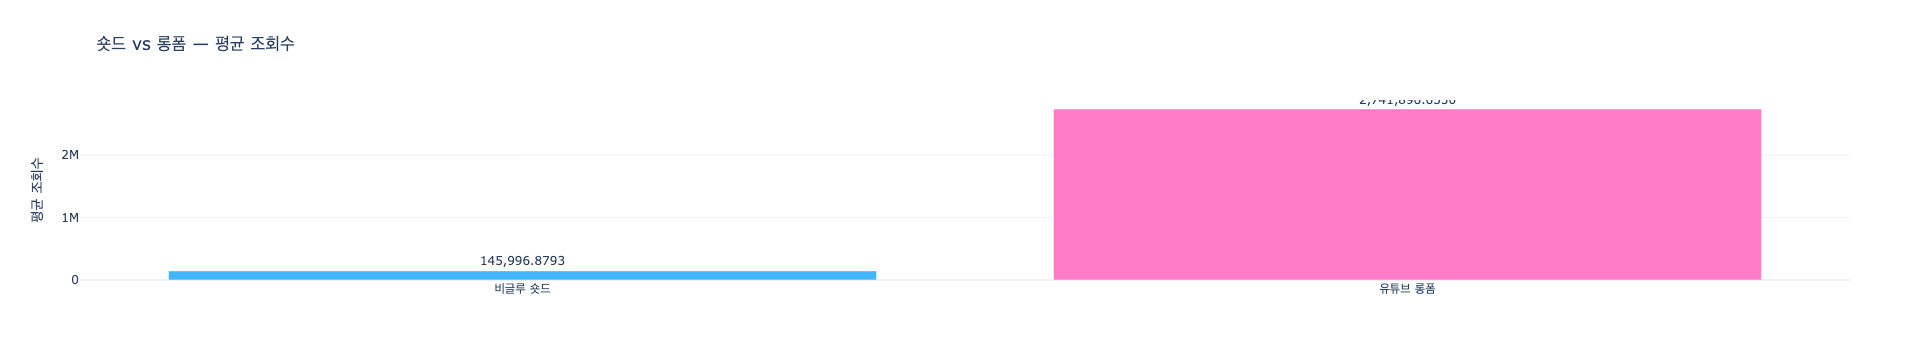

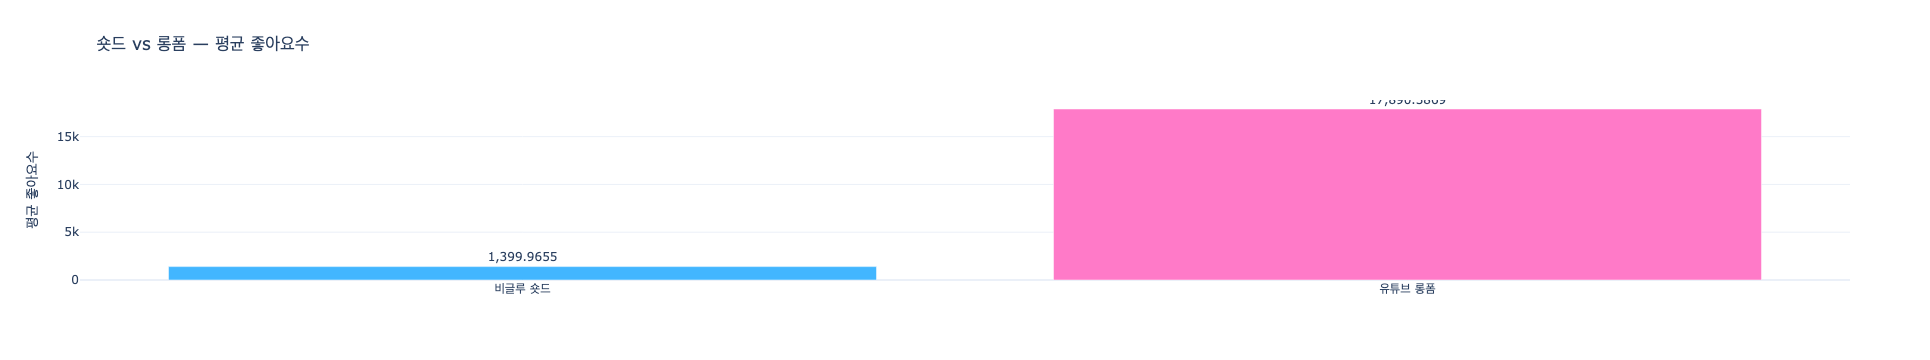

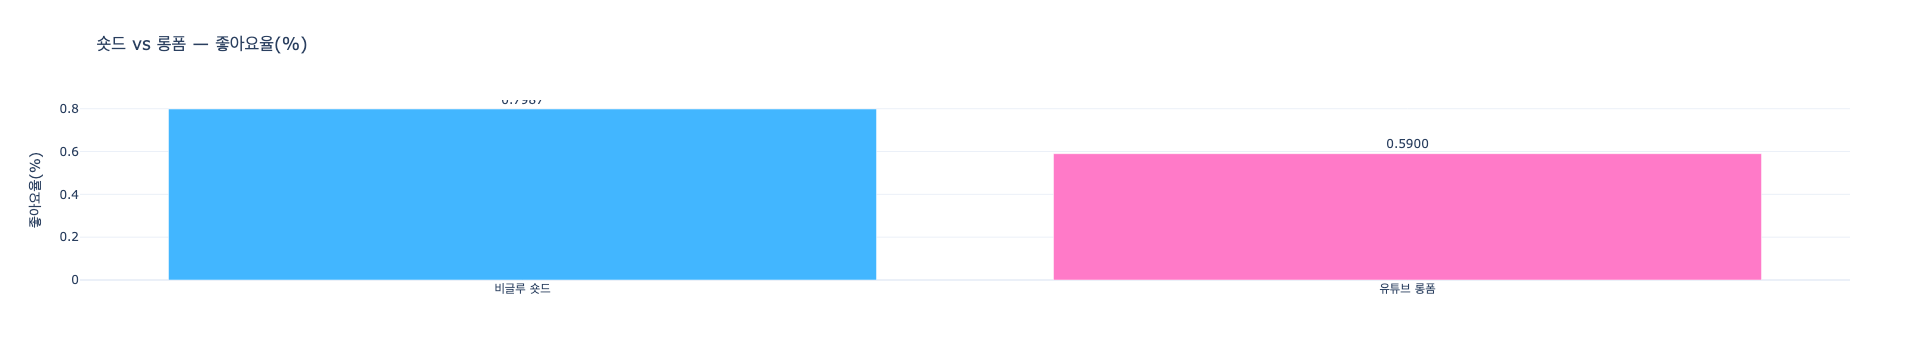

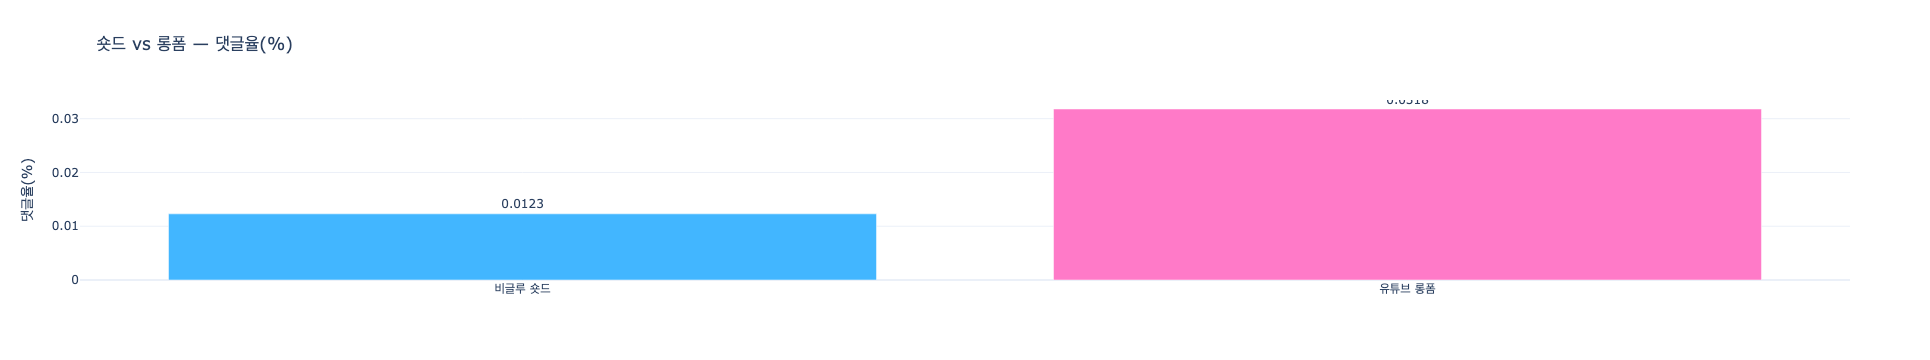

In [6]:
labels   = ['비글루 숏드', '유튜브 롱폼']
metrics  = ['평균 조회수', '평균 좋아요수', '좋아요율(%)', '댓글율(%)']

for metric in metrics:
    values = summary[metric].tolist()
    fig = go.Figure(go.Bar(
        x=labels,
        y=values,
        text=[f'{v:,.4f}' for v in values],
        textposition='outside',
        marker_color=['#42B6FF', '#FF7AC8']
    ))
    fig.update_layout(
        title=f'숏드 vs 롱폼 — {metric}',
        template='plotly_white',
        yaxis_title=metric
    )
    fig.show()

In [11]:
shortform_df.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/vigloo_vs_longform/vigloo_shortform.csv', index=False, encoding='utf-8-sig')
longform_df.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/vigloo_vs_longform/longform_drama.csv', index=False, encoding='utf-8-sig')
summary.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/vigloo_vs_longform/comparison_summary.csv', index=False, encoding='utf-8-sig')
print('CSV 저장 완료')

CSV 저장 완료


In [10]:
%whos DataFrame

Variable       Type         Data/Info
-------------------------------------
longform_df    DataFrame    Shape: (137, 12)
shortform_df   DataFrame    Shape: (58, 11)
summary        DataFrame    Shape: (2, 5)
